# Residual Bootstrap $C_{ij}$

This script compares elastic properties obtained from a fine-tuned MACE interatomic potential with reference DFT data for a set of double half-Heusler structures. For each alloy, the elastic tensor is fitted independently from DFT stresses and MACE-predicted stresses using the same set of strained configurations.

In the linear elastic regime, stress and strain are related as

$\sigma_i = \sigma_i^{(0)} + \sum_j C_{ij}\varepsilon_j ,$

where (C_{ij}) are the elastic constants. For each alloy, ($C^{\mathrm{DFT}}$) and ($C^{\mathrm{MACE}}$) are fitted independently using the same strain set.

The component-wise MACE error is defined as

$\Delta C_{ij} = C_{ij}^{\mathrm{MACE}} - C_{ij}^{\mathrm{DFT}}.$

The script also computes Reuss bulk and shear moduli from the compliance tensor ($S=C^{-1}$), and compares ($B_R$) and ($G_R$) between MACE and DFT.

Bootstrap resampling provides standard deviations and 95% confidence intervals for these metrics. The final output therefore quantifies both the systematic deviation of MACE from DFT and the statistical uncertainty of this deviation across the tested alloy set.

In [12]:
import numpy as np
import pandas as pd

from ase.io import read
from mace.calculators import MACECalculator
from pymatgen.io.ase import AseAtomsAdaptor

from pymatgen.analysis.elasticity.strain import Strain
from pymatgen.analysis.elasticity.stress import Stress
from pymatgen.analysis.elasticity.elastic import ElasticTensor
from pymatgen.analysis.elasticity.strain import DeformedStructureSet
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer


EV_A3_TO_GPA = 160.21766208

extxyz_path = "dhh_test.extxyz"
model_path = "/workspaces/wsl_python/elastic_dhh/dhh_mace_matpes_r2scan_ft_compiled.model"

dft_stress_sign = -1.0
mace_stress_sign = 1.0

n_bootstrap = 2000
seed = 42


calc = MACECalculator(
    model_paths=model_path,
    device="cuda",
    default_dtype="float64",
)


def make_key(atoms):
    return (
        atoms.info["phase"],
        atoms.info["family"],
        atoms.info["alloy"],
    )


def stress_matrix_from_voigt(s):
    return np.array([
        [s[0], s[5], s[4]],
        [s[5], s[1], s[3]],
        [s[4], s[3], s[2]],
    ])

def dft_stress_from_atoms(atoms):
    dft_stress_voigt = (
        dft_stress_sign
        * np.array(atoms.info["REF_stress"])
        * EV_A3_TO_GPA
    )
    return Stress(stress_matrix_from_voigt(dft_stress_voigt))

def mace_stress_from_atoms(atoms):
    atoms_mace = atoms.copy()
    atoms_mace.calc = calc

    mace_stress_voigt = (
        mace_stress_sign
        * atoms_mace.get_stress(voigt=True)
        * EV_A3_TO_GPA
    )
    return Stress(stress_matrix_from_voigt(mace_stress_voigt))

def fit_elastic_tensor(strains, stresses, eq_structure, eq_stress):
    sga = SpacegroupAnalyzer(eq_structure, symprec=1e-3)
    ops = sga.get_point_group_operations(cartesian=True)

    aug_strains = list(strains)
    aug_stresses = list(stresses)

    for op in ops:
        R = op.rotation_matrix

        for strain, stress in zip(strains, stresses):
            e_rot = R @ np.array(strain) @ R.T
            s_rot = R @ np.array(stress) @ R.T

            aug_strains.append(Strain(e_rot))
            aug_stresses.append(Stress(s_rot))

    elastic_tensor = ElasticTensor.from_independent_strains(
        aug_strains,
        aug_stresses,
        eq_stress=eq_stress,
        vasp=False,
    )

    return elastic_tensor.voigt


def reuss_bulk_shear(C):
    S = np.linalg.inv(C)

    B_R = 1.0 / (
        S[0, 0] + S[1, 1] + S[2, 2]
        + 2.0 * (S[0, 1] + S[0, 2] + S[1, 2])
    )

    G_R = 15.0 / (
        4.0 * (S[0, 0] + S[1, 1] + S[2, 2])
        - 4.0 * (S[0, 1] + S[0, 2] + S[1, 2])
        + 3.0 * (S[3, 3] + S[4, 4] + S[5, 5])
    )

    return B_R, G_R


def fit_one_group(atoms_eq, atoms_strains):
    eq_structure = AseAtomsAdaptor.get_structure(atoms_eq)
    dset = DeformedStructureSet(eq_structure, symmetry=True)

    strains = []
    dft_stresses = []
    mace_stresses = []

    for i, atoms in enumerate(atoms_strains):
        strain = dset.deformations[i].green_lagrange_strain

        dft_stresses.append(dft_stress_from_atoms(atoms))
        mace_stresses.append(mace_stress_from_atoms(atoms))

        strains.append(strain)

    dft_eq_stress = dft_stress_from_atoms(atoms_eq)
    mace_eq_stress = mace_stress_from_atoms(atoms_eq)

    C_dft = fit_elastic_tensor(
        strains,
        dft_stresses,
        eq_structure,
        eq_stress=dft_eq_stress,
    )

    C_mace = fit_elastic_tensor(
        strains,
        mace_stresses,
        eq_structure,
        eq_stress=mace_eq_stress,
    )

    return C_dft, C_mace


def bootstrap_errors(df, names, label, n_bootstrap=2000, seed=42):
    rng = np.random.default_rng(seed)

    rows = []

    for name in names:
        d = df[f"{name}_diff"].to_numpy()
        n = len(d)

        point_bias = np.mean(d)
        point_mae = np.mean(np.abs(d))
        point_rmse = np.sqrt(np.mean(d**2))

        bias_boot = []
        mae_boot = []
        rmse_boot = []

        for _ in range(n_bootstrap):
            idx = rng.integers(0, n, size=n)
            db = d[idx]

            bias_boot.append(np.mean(db))
            mae_boot.append(np.mean(np.abs(db)))
            rmse_boot.append(np.sqrt(np.mean(db**2)))

        for metric, point, values in [
            ("bias", point_bias, bias_boot),
            ("mae", point_mae, mae_boot),
            ("rmse", point_rmse, rmse_boot),
        ]:
            values = np.array(values)

            rows.append({
                "type": label,
                "component": name,
                "metric": metric,
                "point_GPa": point,
                "boot_std_GPa": np.std(values, ddof=1),
                "ci95_low_GPa": np.percentile(values, 2.5),
                "ci95_high_GPa": np.percentile(values, 97.5),
            })

    D = np.array([
        df[f"{name}_diff"].to_numpy()
        for name in names
    ]).T

    n = len(D)

    point_bias = np.mean(D)
    point_mae = np.mean(np.abs(D))
    point_rmse = np.sqrt(np.mean(D**2))

    bias_boot = []
    mae_boot = []
    rmse_boot = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        Db = D[idx]

        bias_boot.append(np.mean(Db))
        mae_boot.append(np.mean(np.abs(Db)))
        rmse_boot.append(np.sqrt(np.mean(Db**2)))

    for metric, point, values in [
        ("bias", point_bias, bias_boot),
        ("mae", point_mae, mae_boot),
        ("rmse", point_rmse, rmse_boot),
    ]:
        values = np.array(values)

        rows.append({
            "type": label,
            "component": f"all_{label}",
            "metric": metric,
            "point_GPa": point,
            "boot_std_GPa": np.std(values, ddof=1),
            "ci95_low_GPa": np.percentile(values, 2.5),
            "ci95_high_GPa": np.percentile(values, 97.5),
        })

    return pd.DataFrame(rows)


atoms_all = read(extxyz_path, ":")

atoms_eq_all = [
    atoms for atoms in atoms_all
    if atoms.info["config_type"] == "eq"
]

atoms_strain_all = [
    atoms for atoms in atoms_all
    if atoms.info["config_type"] == "strain"
]

eq_by_key = {
    make_key(atoms): atoms
    for atoms in atoms_eq_all
}

strain_by_key = {}

for atoms in atoms_strain_all:
    key = make_key(atoms)
    strain_by_key.setdefault(key, []).append(atoms)


cij_names = [
    "C11", "C12", "C13", "C14", "C15", "C16",
    "C22", "C23", "C24", "C25", "C26",
    "C33", "C34", "C35", "C36",
    "C44", "C45", "C46",
    "C55", "C56",
    "C66",
]

cij_indices = [
    (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
    (1, 1), (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 2), (2, 3), (2, 4), (2, 5),
    (3, 3), (3, 4), (3, 5),
    (4, 4), (4, 5),
    (5, 5),
]

reuss_names = ["B_R", "G_R"]

rows = []

for key in eq_by_key:
    atoms_eq = eq_by_key[key]
    atoms_strains = strain_by_key[key]

    C_dft, C_mace = fit_one_group(atoms_eq, atoms_strains)
    C_diff = C_mace - C_dft

    B_R_dft, G_R_dft = reuss_bulk_shear(C_dft)
    B_R_mace, G_R_mace = reuss_bulk_shear(C_mace)

    row = {
        "phase": key[0],
        "family": key[1],
        "alloy": key[2],
        "n_strain": len(atoms_strains),

        "B_R_DFT": B_R_dft,
        "B_R_MACE": B_R_mace,
        "B_R_diff": B_R_mace - B_R_dft,

        "G_R_DFT": G_R_dft,
        "G_R_MACE": G_R_mace,
        "G_R_diff": G_R_mace - G_R_dft,
    }

    for name, (i, j) in zip(cij_names, cij_indices):
        row[f"{name}_DFT"] = C_dft[i, j]
        row[f"{name}_MACE"] = C_mace[i, j]
        row[f"{name}_diff"] = C_diff[i, j]

    rows.append(row)


df_elastic = pd.DataFrame(rows)

summary_cij = bootstrap_errors(
    df_elastic,
    cij_names,
    label="Cij",
    n_bootstrap=n_bootstrap,
    seed=seed,
)

summary_reuss = bootstrap_errors(
    df_elastic,
    reuss_names,
    label="Reuss",
    n_bootstrap=n_bootstrap,
    seed=seed + 100,
)

summary = pd.concat(
    [summary_cij, summary_reuss],
    ignore_index=True,
)


df_elastic.to_csv("cij_reuss_mace_vs_dft_per_alloy.csv", index=False)
summary.to_csv("cij_reuss_mace_vs_dft_bootstrap.csv", index=False)

print("All Cij bootstrap:")
print(summary_cij[summary_cij["component"] == "all_Cij"].to_string(index=False))
print()

print("Reuss moduli bootstrap:")
print(summary_reuss.to_string(index=False))
print()

print("MAE by Cij component:")
print(
    summary_cij[summary_cij["metric"] == "mae"]
    .sort_values("point_GPa", ascending=False)
    .to_string(index=False)
)

/home/vscode/.local/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/vscode/.local/lib/python3.12/site-packages/torch/serialization.py:1493: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  warnings.warn(


Using head Default out of ['Default']


/tmp/ipykernel_3863/1912759022.py:85: UserWarning: Extra strain states in strain-stress pairs are neglected in independent strain fitting
  elastic_tensor = ElasticTensor.from_independent_strains(
/tmp/ipykernel_3863/1912759022.py:85: UserWarning: Extra strain states in strain-stress pairs are neglected in independent strain fitting
  elastic_tensor = ElasticTensor.from_independent_strains(


All Cij bootstrap:
type component metric  point_GPa  boot_std_GPa  ci95_low_GPa  ci95_high_GPa
 Cij   all_Cij   bias -16.993984      1.396566    -19.623094     -14.157846
 Cij   all_Cij    mae  16.993986      1.396566     14.157846      19.623094
 Cij   all_Cij   rmse  29.564122      2.265387     24.743988      33.607090

Reuss moduli bootstrap:
 type component metric  point_GPa  boot_std_GPa  ci95_low_GPa  ci95_high_GPa
Reuss       B_R   bias -43.618946      3.543545    -50.365080     -36.815190
Reuss       B_R    mae  43.618946      3.543545     36.815190      50.365080
Reuss       B_R   rmse  45.137417      3.450801     38.043726      51.290605
Reuss       G_R   bias -17.960752      1.358693    -20.659407     -15.210861
Reuss       G_R    mae  17.960752      1.358693     15.210861      20.659407
Reuss       G_R   rmse  18.512085      1.310965     15.886247      21.015046
Reuss all_Reuss   bias -30.789849      2.225700    -34.955507     -26.490220
Reuss all_Reuss    mae  30.789849   

# Sound Velocity Errors

In [40]:
from pymatgen.io.ase import AseAtomsAdaptor


rho_rows = []

for key, atoms_eq in eq_by_key.items():
    phase, family, alloy = key

    eq_structure = AseAtomsAdaptor.get_structure(atoms_eq)

    rho_rows.append({
        "phase": phase,
        "family": family,
        "alloy": alloy,

        "rho_kg_m3": eq_structure.density * 1000.0,
        "v0_ang3_atom": eq_structure.volume / len(eq_structure),
    })


df_rho = pd.DataFrame(rho_rows)

## Shear Velocity Error Propagation

This script propagates the MACE–DFT error in the Reuss shear modulus to the transverse sound velocity.

The transverse sound velocity is calculated as

$
v_t = \sqrt{\frac{G_R}{\rho}},
$

where $G_R$ is the Reuss shear modulus and $\rho$ is the mass density.

For each alloy, the exact MACE–DFT velocity difference is

$
\Delta v_t =
v_t(G_R^{\mathrm{MACE}}) -
v_t(G_R^{\mathrm{DFT}}).
$

A linearized estimate is also computed as

$
\Delta v_t \approx
v_t^{\mathrm{DFT}}
\frac{\Delta G_R}{2G_R^{\mathrm{DFT}}}.
$

The confidence interval of $\Delta G_R$ is propagated to $v_t$ using both the exact square-root expression and the linear approximation. The output compares exact and linearized velocity errors for each alloy and reports their mean values.


In [41]:
import numpy as np
import pandas as pd


df = pd.read_csv("cij_reuss_mace_vs_dft_per_alloy.csv")


# ============================================================
# Get G_R bootstrap bias and CI from summary_reuss
# ============================================================

def get_reuss_error(summary_reuss, component, metric="bias"):
    row = summary_reuss[
        (summary_reuss["component"] == component)
        & (summary_reuss["metric"] == metric)
    ]

    if len(row) != 1:
        raise RuntimeError(
            f"Expected exactly one row for component={component}, metric={metric}, "
            f"but found {len(row)}"
        )

    row = row.iloc[0]

    return (
        float(row["point_GPa"]),
        float(row["ci95_low_GPa"]),
        float(row["ci95_high_GPa"]),
    )


dG_bias, dG_ci_low, dG_ci_high = get_reuss_error(
    summary_reuss,
    component="G_R",
    metric="bias",
)

print("G_R bias:", dG_bias)
print("G_R CI low:", dG_ci_low)
print("G_R CI high:", dG_ci_high)


# ============================================================
# Add structure-specific density
# ============================================================

df = df.merge(
    df_rho[["phase", "family", "alloy", "rho_kg_m3"]],
    on=["phase", "family", "alloy"],
    how="left",
)

if df["rho_kg_m3"].isna().any():
    missing = df[df["rho_kg_m3"].isna()][["phase", "family", "alloy"]]
    raise RuntimeError(f"Missing rho_kg_m3 for some structures:\n{missing}")


# ============================================================
# Transverse sound velocity error
# ============================================================

G_dft = df["G_R_DFT"].to_numpy()
G_mace = df["G_R_MACE"].to_numpy()
dG = df["G_R_diff"].to_numpy()

rho = df["rho_kg_m3"].to_numpy()


def vt(G_GPa, rho_kg_m3):
    return np.sqrt(G_GPa * 1e9 / rho_kg_m3)


vt_dft = vt(G_dft, rho)
vt_mace = vt(G_mace, rho)

dvt_exact = vt_mace - vt_dft
dvt_linear = vt_dft * dG / (2.0 * G_dft)

dvt_exact_ci_low = vt(G_dft + dG_ci_low, rho) - vt_dft
dvt_exact_ci_high = vt(G_dft + dG_ci_high, rho) - vt_dft

dvt_linear_ci_low = vt_dft * dG_ci_low / (2.0 * G_dft)
dvt_linear_ci_high = vt_dft * dG_ci_high / (2.0 * G_dft)


out = df[[
    "phase",
    "family",
    "alloy",
    "rho_kg_m3",
    "G_R_DFT",
    "G_R_MACE",
    "G_R_diff",
]].copy()

out["vt_DFT_m_s"] = vt_dft
out["vt_MACE_m_s"] = vt_mace

out["dvt_exact_m_s"] = dvt_exact
out["dvt_exact_ci_low_m_s"] = dvt_exact_ci_low
out["dvt_exact_ci_high_m_s"] = dvt_exact_ci_high

out["dvt_linear_m_s"] = dvt_linear
out["dvt_linear_ci_low_m_s"] = dvt_linear_ci_low
out["dvt_linear_ci_high_m_s"] = dvt_linear_ci_high

out["linear_minus_exact_m_s"] = dvt_linear - dvt_exact
out["relative_difference_percent"] = (
    100.0 * (dvt_linear - dvt_exact) / dvt_exact
)

df_vt = out.copy()

print(out.to_string(index=False))

print()
print("Mean exact Delta vt, m/s:", np.mean(dvt_exact))
print("Mean exact CI low, m/s:", np.mean(dvt_exact_ci_low))
print("Mean exact CI high, m/s:", np.mean(dvt_exact_ci_high))

print()
print("Mean linear Delta vt, m/s:", np.mean(dvt_linear))
print("Mean linear CI low, m/s:", np.mean(dvt_linear_ci_low))
print("Mean linear CI high, m/s:", np.mean(dvt_linear_ci_high))

G_R bias: -17.960752269886072
G_R CI low: -20.659407228798884
G_R CI high: -15.21086063282542
phase   family        alloy    rho_kg_m3   G_R_DFT  G_R_MACE   G_R_diff  vt_DFT_m_s  vt_MACE_m_s  dvt_exact_m_s  dvt_exact_ci_low_m_s  dvt_exact_ci_high_m_s  dvt_linear_m_s  dvt_linear_ci_low_m_s  dvt_linear_ci_high_m_s  linear_minus_exact_m_s  relative_difference_percent
I-42d X1X2Y2Z2 ZrMo_Os2_Bi2 12841.013807 56.774710 40.947120 -15.827590 2102.702383  1785.714493    -316.987891           -425.652521            -303.590276     -293.094513            -382.569850             -281.673942               23.893377                    -7.537631
I-42d X1X2Y2Z2 TiCr_Fe2_As2  7255.359018 94.933645 68.752923 -26.180723 3617.267491  3078.336762    -538.930729           -417.711980            -302.433553     -498.783528            -393.593872             -289.790576               40.147201                    -7.449418
I-42d X1X2Y2Z2   YV_Ag2_Ga2  6804.980325 23.167888 14.545702  -8.622187 1845.141976  14

## Longitudinal Sound Velocity Error

This script estimates the effect of MACE–DFT errors in $B_R$ and $G_R$ on the longitudinal sound velocity.

The velocity is calculated as

$
v_l = \sqrt{\frac{B_R + 4G_R/3}{\rho}}.
$

The exact velocity error is

$
\Delta v_l =
v_l^{\mathrm{MACE}} -
v_l^{\mathrm{DFT}}.
$

A linear approximation is:

$
\Delta v_l \approx
v_l^{\mathrm{DFT}}
\frac{\Delta B_R + 4\Delta G_R/3}
{2(B_R^{\mathrm{DFT}} + 4G_R^{\mathrm{DFT}}/3)}.
$

The script compares exact and linearized estimates of $\Delta v_l$ and reports their mean values.


In [42]:
import numpy as np
import pandas as pd


df = pd.read_csv("cij_reuss_mace_vs_dft_per_alloy.csv")


# ============================================================
# Get B_R and G_R bootstrap bias and CI from summary_reuss
# ============================================================

def get_reuss_error(summary_reuss, component, metric="bias"):
    row = summary_reuss[
        (summary_reuss["component"] == component)
        & (summary_reuss["metric"] == metric)
    ]

    if len(row) != 1:
        raise RuntimeError(
            f"Expected exactly one row for component={component}, metric={metric}, "
            f"but found {len(row)}"
        )

    row = row.iloc[0]

    return (
        float(row["point_GPa"]),
        float(row["ci95_low_GPa"]),
        float(row["ci95_high_GPa"]),
    )


dB_bias, dB_ci_low, dB_ci_high = get_reuss_error(
    summary_reuss,
    component="B_R",
    metric="bias",
)

dG_bias, dG_ci_low, dG_ci_high = get_reuss_error(
    summary_reuss,
    component="G_R",
    metric="bias",
)

print("B_R bias:", dB_bias)
print("B_R CI low:", dB_ci_low)
print("B_R CI high:", dB_ci_high)

print("G_R bias:", dG_bias)
print("G_R CI low:", dG_ci_low)
print("G_R CI high:", dG_ci_high)


# ============================================================
# Add structure-specific density
# ============================================================

df = df.merge(
    df_rho[["phase", "family", "alloy", "rho_kg_m3"]],
    on=["phase", "family", "alloy"],
    how="left",
)

if df["rho_kg_m3"].isna().any():
    missing = df[df["rho_kg_m3"].isna()][["phase", "family", "alloy"]]
    raise RuntimeError(f"Missing rho_kg_m3 for some structures:\n{missing}")


# ============================================================
# Longitudinal sound velocity error
# ============================================================

B_dft = df["B_R_DFT"].to_numpy()
G_dft = df["G_R_DFT"].to_numpy()

B_mace = df["B_R_MACE"].to_numpy()
G_mace = df["G_R_MACE"].to_numpy()

dB = df["B_R_diff"].to_numpy()
dG = df["G_R_diff"].to_numpy()

rho = df["rho_kg_m3"].to_numpy()


def vl(B_GPa, G_GPa, rho_kg_m3):
    return np.sqrt((B_GPa + 4.0 * G_GPa / 3.0) * 1e9 / rho_kg_m3)


vl_dft = vl(B_dft, G_dft, rho)
vl_mace = vl(B_mace, G_mace, rho)

dvl_exact = vl_mace - vl_dft

M_dft = B_dft + 4.0 * G_dft / 3.0
dM = dB + 4.0 * dG / 3.0

dvl_linear = vl_dft * dM / (2.0 * M_dft)

dvl_exact_ci_low = (
    vl(B_dft + dB_ci_low, G_dft + dG_ci_low, rho)
    - vl_dft
)

dvl_exact_ci_high = (
    vl(B_dft + dB_ci_high, G_dft + dG_ci_high, rho)
    - vl_dft
)

dM_ci_low = dB_ci_low + 4.0 * dG_ci_low / 3.0
dM_ci_high = dB_ci_high + 4.0 * dG_ci_high / 3.0

dvl_linear_ci_low = vl_dft * dM_ci_low / (2.0 * M_dft)
dvl_linear_ci_high = vl_dft * dM_ci_high / (2.0 * M_dft)


out = df[[
    "phase",
    "family",
    "alloy",
    "rho_kg_m3",
    "B_R_DFT",
    "B_R_MACE",
    "B_R_diff",
    "G_R_DFT",
    "G_R_MACE",
    "G_R_diff",
]].copy()

out["vl_DFT_m_s"] = vl_dft
out["vl_MACE_m_s"] = vl_mace

out["dvl_exact_m_s"] = dvl_exact
out["dvl_exact_ci_low_m_s"] = dvl_exact_ci_low
out["dvl_exact_ci_high_m_s"] = dvl_exact_ci_high

out["dvl_linear_m_s"] = dvl_linear
out["dvl_linear_ci_low_m_s"] = dvl_linear_ci_low
out["dvl_linear_ci_high_m_s"] = dvl_linear_ci_high

out["linear_minus_exact_m_s"] = dvl_linear - dvl_exact
out["relative_difference_percent"] = (
    100.0 * (dvl_linear - dvl_exact) / dvl_exact
)

df_vl = out.copy()

print(out.to_string(index=False))

print()
print("Mean exact Delta vl, m/s:", np.mean(dvl_exact))
print("Mean exact CI low, m/s:", np.mean(dvl_exact_ci_low))
print("Mean exact CI high, m/s:", np.mean(dvl_exact_ci_high))

print()
print("Mean linear Delta vl, m/s:", np.mean(dvl_linear))
print("Mean linear CI low, m/s:", np.mean(dvl_linear_ci_low))
print("Mean linear CI high, m/s:", np.mean(dvl_linear_ci_high))

B_R bias: -43.61894596281302
B_R CI low: -50.36508048694034
B_R CI high: -36.815189682714056
G_R bias: -17.960752269886072
G_R CI low: -20.659407228798884
G_R CI high: -15.21086063282542
phase   family        alloy    rho_kg_m3    B_R_DFT   B_R_MACE   B_R_diff   G_R_DFT  G_R_MACE   G_R_diff  vl_DFT_m_s  vl_MACE_m_s  dvl_exact_m_s  dvl_exact_ci_low_m_s  dvl_exact_ci_high_m_s  dvl_linear_m_s  dvl_linear_ci_low_m_s  dvl_linear_ci_high_m_s  linear_minus_exact_m_s  relative_difference_percent
I-42d X1X2Y2Z2 ZrMo_Os2_Bi2 12841.013807 168.619974 122.602974 -46.017000 56.774710 40.947120 -15.827590 4361.937983  3714.763253    -647.174730           -762.055971            -543.548426     -599.164518            -695.488163             -509.682184               48.010212                    -7.418431
I-42d X1X2Y2Z2 TiCr_Fe2_As2  7255.359018 196.252608 139.771909 -56.480699 94.933645 68.752923 -26.180723 6670.494470  5647.966035   -1022.528435           -860.408828            -618.556220     -944.15

## Mean Sound Velocity Error

This script estimates the effect of MACE–DFT errors in $B_R$ and $G_R$ on the mean sound velocity.

The mean sound velocity is calculated from transverse and longitudinal velocities:

$
v_m =
\left[
\frac{1}{3}
\left(
\frac{1}{v_l^3}
+
\frac{2}{v_t^3}
\right)
\right]^{-1/3}.
$

The exact error is

$
\Delta v_m =
v_m^{\mathrm{MACE}} -
v_m^{\mathrm{DFT}}.
$

A linearized estimate is also computed by propagating relative errors in $v_l$ and $v_t$:

$
\Delta v_m \approx
v_m^{\mathrm{DFT}}
\left(
w_l \frac{\Delta v_l}{v_l}
+
w_t \frac{\Delta v_t}{v_t}
\right).
$

The script compares exact and linearized estimates of $\Delta v_m$ and reports their mean values.


In [43]:
import numpy as np
import pandas as pd


df = pd.read_csv("cij_reuss_mace_vs_dft_per_alloy.csv")


# ============================================================
# Get B_R and G_R bootstrap bias and CI from summary_reuss
# ============================================================

def get_reuss_error(summary_reuss, component, metric="bias"):
    row = summary_reuss[
        (summary_reuss["component"] == component)
        & (summary_reuss["metric"] == metric)
    ]

    if len(row) != 1:
        raise RuntimeError(
            f"Expected exactly one row for component={component}, metric={metric}, "
            f"but found {len(row)}"
        )

    row = row.iloc[0]

    return (
        float(row["point_GPa"]),
        float(row["ci95_low_GPa"]),
        float(row["ci95_high_GPa"]),
    )


dB_bias, dB_ci_low, dB_ci_high = get_reuss_error(
    summary_reuss,
    component="B_R",
    metric="bias",
)

dG_bias, dG_ci_low, dG_ci_high = get_reuss_error(
    summary_reuss,
    component="G_R",
    metric="bias",
)

print("B_R bias:", dB_bias)
print("B_R CI low:", dB_ci_low)
print("B_R CI high:", dB_ci_high)

print("G_R bias:", dG_bias)
print("G_R CI low:", dG_ci_low)
print("G_R CI high:", dG_ci_high)


# ============================================================
# Add structure-specific density
# ============================================================

df = df.merge(
    df_rho[["phase", "family", "alloy", "rho_kg_m3"]],
    on=["phase", "family", "alloy"],
    how="left",
)

if df["rho_kg_m3"].isna().any():
    missing = df[df["rho_kg_m3"].isna()][["phase", "family", "alloy"]]
    raise RuntimeError(f"Missing rho_kg_m3 for some structures:\n{missing}")


# ============================================================
# Mean sound velocity error
# ============================================================

B_dft = df["B_R_DFT"].to_numpy()
G_dft = df["G_R_DFT"].to_numpy()

B_mace = df["B_R_MACE"].to_numpy()
G_mace = df["G_R_MACE"].to_numpy()

dB = df["B_R_diff"].to_numpy()
dG = df["G_R_diff"].to_numpy()

rho = df["rho_kg_m3"].to_numpy()


def vt(G_GPa, rho_kg_m3):
    return np.sqrt(G_GPa * 1e9 / rho_kg_m3)


def vl(B_GPa, G_GPa, rho_kg_m3):
    return np.sqrt((B_GPa + 4.0 * G_GPa / 3.0) * 1e9 / rho_kg_m3)


def vm(vl_, vt_):
    return (
        (1.0 / 3.0)
        * (1.0 / vl_**3 + 2.0 / vt_**3)
    ) ** (-1.0 / 3.0)


vt_dft = vt(G_dft, rho)
vl_dft = vl(B_dft, G_dft, rho)
vm_dft = vm(vl_dft, vt_dft)

vt_mace = vt(G_mace, rho)
vl_mace = vl(B_mace, G_mace, rho)
vm_mace = vm(vl_mace, vt_mace)

dvm_exact = vm_mace - vm_dft


# Linear approximation

S = vl_dft**(-3) + 2.0 * vt_dft**(-3)

w_l = vl_dft**(-3) / S
w_t = 2.0 * vt_dft**(-3) / S

dvt_rel = dG / (2.0 * G_dft)

dvl_rel = (
    dB + 4.0 * dG / 3.0
) / (
    2.0 * (B_dft + 4.0 * G_dft / 3.0)
)

dvm_linear = vm_dft * (
    w_l * dvl_rel
    + w_t * dvt_rel
)


# Exact CI propagation

vm_ci_low = vm(
    vl(B_dft + dB_ci_low, G_dft + dG_ci_low, rho),
    vt(G_dft + dG_ci_low, rho),
)

vm_ci_high = vm(
    vl(B_dft + dB_ci_high, G_dft + dG_ci_high, rho),
    vt(G_dft + dG_ci_high, rho),
)

dvm_exact_ci_low = vm_ci_low - vm_dft
dvm_exact_ci_high = vm_ci_high - vm_dft


# Linear CI propagation

dvt_rel_ci_low = dG_ci_low / (2.0 * G_dft)
dvt_rel_ci_high = dG_ci_high / (2.0 * G_dft)

dvl_rel_ci_low = (
    dB_ci_low + 4.0 * dG_ci_low / 3.0
) / (
    2.0 * (B_dft + 4.0 * G_dft / 3.0)
)

dvl_rel_ci_high = (
    dB_ci_high + 4.0 * dG_ci_high / 3.0
) / (
    2.0 * (B_dft + 4.0 * G_dft / 3.0)
)

dvm_linear_ci_low = vm_dft * (
    w_l * dvl_rel_ci_low
    + w_t * dvt_rel_ci_low
)

dvm_linear_ci_high = vm_dft * (
    w_l * dvl_rel_ci_high
    + w_t * dvt_rel_ci_high
)


out = df[[
    "phase",
    "family",
    "alloy",
    "rho_kg_m3",
    "B_R_DFT",
    "B_R_MACE",
    "B_R_diff",
    "G_R_DFT",
    "G_R_MACE",
    "G_R_diff",
]].copy()

out["vm_DFT_m_s"] = vm_dft
out["vm_MACE_m_s"] = vm_mace

out["dvm_exact_m_s"] = dvm_exact
out["dvm_exact_ci_low_m_s"] = dvm_exact_ci_low
out["dvm_exact_ci_high_m_s"] = dvm_exact_ci_high

out["dvm_linear_m_s"] = dvm_linear
out["dvm_linear_ci_low_m_s"] = dvm_linear_ci_low
out["dvm_linear_ci_high_m_s"] = dvm_linear_ci_high

out["linear_minus_exact_m_s"] = dvm_linear - dvm_exact
out["relative_difference_percent"] = (
    100.0 * (dvm_linear - dvm_exact) / dvm_exact
)

df_vm = out.copy()

print(out.to_string(index=False))

print()
print("Mean exact Delta vm, m/s:", np.mean(dvm_exact))
print("Mean exact CI low, m/s:", np.mean(dvm_exact_ci_low))
print("Mean exact CI high, m/s:", np.mean(dvm_exact_ci_high))

print()
print("Mean linear Delta vm, m/s:", np.mean(dvm_linear))
print("Mean linear CI low, m/s:", np.mean(dvm_linear_ci_low))
print("Mean linear CI high, m/s:", np.mean(dvm_linear_ci_high))

B_R bias: -43.61894596281302
B_R CI low: -50.36508048694034
B_R CI high: -36.815189682714056
G_R bias: -17.960752269886072
G_R CI low: -20.659407228798884
G_R CI high: -15.21086063282542
phase   family        alloy    rho_kg_m3    B_R_DFT   B_R_MACE   B_R_diff   G_R_DFT  G_R_MACE   G_R_diff  vm_DFT_m_s  vm_MACE_m_s  dvm_exact_m_s  dvm_exact_ci_low_m_s  dvm_exact_ci_high_m_s  dvm_linear_m_s  dvm_linear_ci_low_m_s  dvm_linear_ci_high_m_s  linear_minus_exact_m_s  relative_difference_percent
I-42d X1X2Y2Z2 ZrMo_Os2_Bi2 12841.013807 168.619974 122.602974 -46.017000 56.774710 40.947120 -15.827590 2363.663019  2007.631921    -356.031098           -475.220369            -338.894323     -329.215497            -427.229142             -314.486645               26.815601                    -7.531814
I-42d X1X2Y2Z2 TiCr_Fe2_As2  7255.359018 196.252608 139.771909 -56.480699 94.933645 68.752923 -26.180723 4036.196124  3433.555313    -602.640810           -470.231980            -340.229156     -557.63

# Debye Temperature Error

This script estimates how MACE–DFT errors in $B_R$ and $G_R$ affect the Debye temperature.

The Debye temperature is calculated as

$
\Theta_D =
\frac{\hbar}{k_B}
\left(
\frac{6\pi^2}{V_0}
\right)^{1/3}
v_m,
$

where $V_0$ is the volume per atom and $v_m$ is the mean sound velocity.

The exact error is

$
\Delta \Theta_D =
\Theta_D^{\mathrm{MACE}} -
\Theta_D^{\mathrm{DFT}}.
$

A linearized estimate is obtained from the relative error in $v_m$:

$
\Delta \Theta_D \approx
\Theta_D^{\mathrm{DFT}}
\left(
w_l \frac{\Delta v_l}{v_l}
+
w_t \frac{\Delta v_t}{v_t}
\right).
$

The script compares exact and linearized estimates of $\Delta \Theta_D$ and reports their mean values.


In [45]:
import numpy as np
import pandas as pd


df = pd.read_csv("cij_reuss_mace_vs_dft_per_alloy.csv")


# ============================================================
# Get B_R and G_R bootstrap bias and CI from summary_reuss
# ============================================================

def get_reuss_error(summary_reuss, component, metric="bias"):
    row = summary_reuss[
        (summary_reuss["component"] == component)
        & (summary_reuss["metric"] == metric)
    ]

    if len(row) != 1:
        raise RuntimeError(
            f"Expected exactly one row for component={component}, metric={metric}, "
            f"but found {len(row)}"
        )

    row = row.iloc[0]

    return (
        float(row["point_GPa"]),
        float(row["ci95_low_GPa"]),
        float(row["ci95_high_GPa"]),
    )


dB_bias, dB_ci_low, dB_ci_high = get_reuss_error(
    summary_reuss,
    component="B_R",
    metric="bias",
)

dG_bias, dG_ci_low, dG_ci_high = get_reuss_error(
    summary_reuss,
    component="G_R",
    metric="bias",
)

print("B_R bias:", dB_bias)
print("B_R CI low:", dB_ci_low)
print("B_R CI high:", dB_ci_high)

print("G_R bias:", dG_bias)
print("G_R CI low:", dG_ci_low)
print("G_R CI high:", dG_ci_high)


# ============================================================
# Add structure-specific density and volume per atom
# ============================================================

df = df.merge(
    df_rho[[
        "phase",
        "family",
        "alloy",
        "rho_kg_m3",
        "v0_ang3_atom",
    ]],
    on=["phase", "family", "alloy"],
    how="left",
)

if df["rho_kg_m3"].isna().any():
    missing = df[df["rho_kg_m3"].isna()][["phase", "family", "alloy"]]
    raise RuntimeError(f"Missing rho_kg_m3 for some structures:\n{missing}")

if df["v0_ang3_atom"].isna().any():
    missing = df[df["v0_ang3_atom"].isna()][["phase", "family", "alloy"]]
    raise RuntimeError(f"Missing v0_ang3_atom for some structures:\n{missing}")


# ============================================================
# Debye temperature error
# ============================================================

hbar = 1.054571817e-34  # J*s
kB = 1.380649e-23       # J/K

B_dft = df["B_R_DFT"].to_numpy()
G_dft = df["G_R_DFT"].to_numpy()

B_mace = df["B_R_MACE"].to_numpy()
G_mace = df["G_R_MACE"].to_numpy()

dB = df["B_R_diff"].to_numpy()
dG = df["G_R_diff"].to_numpy()

rho = df["rho_kg_m3"].to_numpy()
v0_ang3_atom = df["v0_ang3_atom"].to_numpy()


def vt(G_GPa, rho_kg_m3):
    return np.sqrt(G_GPa * 1e9 / rho_kg_m3)


def vl(B_GPa, G_GPa, rho_kg_m3):
    return np.sqrt((B_GPa + 4.0 * G_GPa / 3.0) * 1e9 / rho_kg_m3)


def vm(vl_, vt_):
    return (
        (1.0 / 3.0)
        * (1.0 / vl_**3 + 2.0 / vt_**3)
    ) ** (-1.0 / 3.0)


def theta_debye(vm_, v0_ang3_atom_):
    v0_m3_atom = v0_ang3_atom_ * 1e-30

    A_debye = (
        hbar / kB
        * (6.0 * np.pi**2 / v0_m3_atom) ** (1.0 / 3.0)
    )

    return A_debye * vm_


vt_dft = vt(G_dft, rho)
vl_dft = vl(B_dft, G_dft, rho)
vm_dft = vm(vl_dft, vt_dft)
theta_dft = theta_debye(vm_dft, v0_ang3_atom)

vt_mace = vt(G_mace, rho)
vl_mace = vl(B_mace, G_mace, rho)
vm_mace = vm(vl_mace, vt_mace)
theta_mace = theta_debye(vm_mace, v0_ang3_atom)

dtheta_exact = theta_mace - theta_dft


# ============================================================
# Linear approximation
# ============================================================

S = vl_dft**(-3) + 2.0 * vt_dft**(-3)

w_l = vl_dft**(-3) / S
w_t = 2.0 * vt_dft**(-3) / S

dvt_rel = dG / (2.0 * G_dft)

dvl_rel = (
    dB + 4.0 * dG / 3.0
) / (
    2.0 * (B_dft + 4.0 * G_dft / 3.0)
)

dtheta_linear = theta_dft * (
    w_l * dvl_rel
    + w_t * dvt_rel
)


# ============================================================
# Exact CI propagation
# ============================================================

vm_ci_low = vm(
    vl(B_dft + dB_ci_low, G_dft + dG_ci_low, rho),
    vt(G_dft + dG_ci_low, rho),
)

vm_ci_high = vm(
    vl(B_dft + dB_ci_high, G_dft + dG_ci_high, rho),
    vt(G_dft + dG_ci_high, rho),
)

theta_ci_low = theta_debye(vm_ci_low, v0_ang3_atom)
theta_ci_high = theta_debye(vm_ci_high, v0_ang3_atom)

dtheta_exact_ci_low = theta_ci_low - theta_dft
dtheta_exact_ci_high = theta_ci_high - theta_dft


# ============================================================
# Linear CI propagation
# ============================================================

dvt_rel_ci_low = dG_ci_low / (2.0 * G_dft)
dvt_rel_ci_high = dG_ci_high / (2.0 * G_dft)

dvl_rel_ci_low = (
    dB_ci_low + 4.0 * dG_ci_low / 3.0
) / (
    2.0 * (B_dft + 4.0 * G_dft / 3.0)
)

dvl_rel_ci_high = (
    dB_ci_high + 4.0 * dG_ci_high / 3.0
) / (
    2.0 * (B_dft + 4.0 * G_dft / 3.0)
)

dtheta_linear_ci_low = theta_dft * (
    w_l * dvl_rel_ci_low
    + w_t * dvt_rel_ci_low
)

dtheta_linear_ci_high = theta_dft * (
    w_l * dvl_rel_ci_high
    + w_t * dvt_rel_ci_high
)


out = df[[
    "phase",
    "family",
    "alloy",
    "rho_kg_m3",
    "v0_ang3_atom",
    "B_R_DFT",
    "B_R_MACE",
    "B_R_diff",
    "G_R_DFT",
    "G_R_MACE",
    "G_R_diff",
]].copy()

out["theta_DFT_K"] = theta_dft
out["theta_MACE_K"] = theta_mace

out["dtheta_exact_K"] = dtheta_exact
out["dtheta_exact_ci_low_K"] = dtheta_exact_ci_low
out["dtheta_exact_ci_high_K"] = dtheta_exact_ci_high

out["dtheta_linear_K"] = dtheta_linear
out["dtheta_linear_ci_low_K"] = dtheta_linear_ci_low
out["dtheta_linear_ci_high_K"] = dtheta_linear_ci_high

out["linear_minus_exact_K"] = dtheta_linear - dtheta_exact
out["relative_difference_percent"] = (
    100.0 * (dtheta_linear - dtheta_exact) / dtheta_exact
)

df_theta = out.copy()

print(out.to_string(index=False))

print()
print("Mean exact Delta theta_D, K:", np.mean(dtheta_exact))
print("Mean exact CI low, K:", np.mean(dtheta_exact_ci_low))
print("Mean exact CI high, K:", np.mean(dtheta_exact_ci_high))

print()
print("Mean linear Delta theta_D, K:", np.mean(dtheta_linear))
print("Mean linear CI low, K:", np.mean(dtheta_linear_ci_low))
print("Mean linear CI high, K:", np.mean(dtheta_linear_ci_high))


# Save for later Slack uncertainty propagation
DELTA_THETA_D_K_EXACT = float(abs(np.mean(dtheta_exact)))
DELTA_THETA_D_K_LINEAR = float(abs(np.mean(dtheta_linear)))

DELTA_THETA_D_K = DELTA_THETA_D_K_LINEAR

B_R bias: -43.61894596281302
B_R CI low: -50.36508048694034
B_R CI high: -36.815189682714056
G_R bias: -17.960752269886072
G_R CI low: -20.659407228798884
G_R CI high: -15.21086063282542
phase   family        alloy    rho_kg_m3  v0_ang3_atom    B_R_DFT   B_R_MACE   B_R_diff   G_R_DFT  G_R_MACE   G_R_diff  theta_DFT_K  theta_MACE_K  dtheta_exact_K  dtheta_exact_ci_low_K  dtheta_exact_ci_high_K  dtheta_linear_K  dtheta_linear_ci_low_K  dtheta_linear_ci_high_K  linear_minus_exact_K  relative_difference_percent
I-42d X1X2Y2Z2 ZrMo_Os2_Bi2 12841.013807     21.241859 168.619974 122.602974 -46.017000 56.774710 40.947120 -15.827590   254.096057    215.822371      -38.273687             -51.086649              -36.431467       -35.390984              -45.927545               -33.807618              2.882703                    -7.531814
I-42d X1X2Y2Z2 TiCr_Fe2_As2  7255.359018     13.785504 196.252608 139.771909 -56.480699 94.933645 68.752923 -26.180723   501.157911    426.330474      -74.827437

# EOS-Induced Uncertainty of the Grüneisen Parameter

The Grüneisen parameter was recalculated from the same energy–volume data using several equation-of-state models. For each material, $\gamma$ was computed independently with the Murnaghan, Birch, Birch–Murnaghan, Vinet, and Poirier–Tarantola EOS forms.

The EOS-induced uncertainty was estimated from the standard deviation of $\gamma$ across the EOS models for each compound:

$\Delta \gamma_{\mathrm{EOS},i} = \mathrm{std} \left( \gamma_i^{\mathrm{EOS}} \right).$

Only compounds for which all EOS models produced finite positive values of $\gamma$ were retained. Large high-$\gamma$ outliers were excluded from the final uncertainty estimate.

The typical single-material EOS-induced uncertainty was then taken as the median value of the per-compound standard deviations:

$\Delta \gamma_{\mathrm{EOS}}=\mathrm{median}\left(\Delta \gamma_{\mathrm{EOS},i}\right).$

This value was used as a conservative estimate of the uncertainty in $\gamma$ for subsequent propagation to the Slack lattice thermal conductivity.

In [46]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

from pymatgen.core import Structure
from pymatgen.analysis.quasiharmonic import QuasiharmonicDebyeApprox


EV_JSON = Path("energy_volume_data.json")
RESULTS_JSON = Path("elastic_gruneisen_results_final_mace.json")

OUT_LONG = Path("gamma_by_eos_long.csv")
OUT_GAMMA = Path("gamma_eos_model_spread_per_alloy.csv")
OUT_SUMMARY = Path("gamma_eos_model_spread_summary.csv")

MACE_SOURCE = "derived_properties_mace_finetuned"

EOS_LIST = [
    "murnaghan",
    "birch",
    "birch_murnaghan",
    "vinet",
    "pourier_tarantola",
]

ONLY_POSITIVE_GAMMA = True
MAX_GAMMA_FOR_ANALYSIS = 8.0


def make_ev_lookup(rows):
    lookup = {}

    for row in rows:
        family = row.get("Family")
        alloy = row.get("Alloy")

        for phase, block in row.items():
            if phase in ("Family", "Alloy"):
                continue

            if not isinstance(block, dict):
                continue

            if "E" not in block or "V" not in block:
                continue

            E = np.array(block["E"], dtype=float)
            V = np.array(block["V"], dtype=float)

            if len(E) != len(V) or len(E) < 4:
                continue

            order = np.argsort(V)

            lookup[(phase, family, alloy)] = {
                "E": E[order],
                "V": V[order],
            }

    return lookup


def make_structure_lookup(rows):
    lookup = {}

    for row in rows:
        family = row.get("Family")
        alloy = row.get("Alloy")

        for phase, block in row.items():
            if phase in ("Family", "Alloy", "E"):
                continue

            if not isinstance(block, dict):
                continue

            if "structure" not in block:
                continue

            props = (
                block
                .get("elastic", {})
                .get(MACE_SOURCE, {})
            )

            poisson = props.get("homogeneous_poisson")

            if poisson is None:
                continue

            try:
                structure = Structure.from_dict(block["structure"])
            except Exception:
                continue

            lookup[(phase, family, alloy)] = {
                "structure": structure,
                "poisson": float(poisson),
            }

    return lookup


def gamma_from_ev(V, E, structure, poisson, eos):
    qha = QuasiharmonicDebyeApprox(
        energies=E.tolist(),
        volumes=V.tolist(),
        structure=structure,
        t_min=1.0,
        t_step=1.0,
        t_max=1.0,
        eos=eos,
        pressure=0.0,
        poisson=float(poisson),
        use_mie_gruneisen=False,
        anharmonic_contribution=False,
    )

    fit = qha.ev_eos_fit
    v0 = float(fit.v0)

    candidate_volumes = [
        v0,
        float(V[len(V) // 2]),
        float(V.mean()),
        float(V.min()),
        float(V.max()),
    ]

    for volume in candidate_volumes:
        try:
            gamma = float(qha.gruneisen_parameter(1.0, volume))

            if np.isfinite(gamma):
                return gamma, fit

        except Exception:
            continue

    raise RuntimeError("Failed to calculate gamma")


def eos_rmse_meV(V, E, fit):
    E_fit = np.array([fit.func(float(v)) for v in V])
    residuals = E - E_fit

    return float(np.sqrt(np.mean(residuals**2)) * 1000.0)


ev_rows = json.loads(EV_JSON.read_text(encoding="utf-8"))
result_rows = json.loads(RESULTS_JSON.read_text(encoding="utf-8"))

ev_lookup = make_ev_lookup(ev_rows)
structure_lookup = make_structure_lookup(result_rows)

rows = []

for key in sorted(structure_lookup):
    if key not in ev_lookup:
        continue

    phase, family, alloy = key

    V = ev_lookup[key]["V"]
    E = ev_lookup[key]["E"]

    structure = structure_lookup[key]["structure"]
    poisson = structure_lookup[key]["poisson"]

    for eos in EOS_LIST:
        try:
            gamma, fit = gamma_from_ev(
                V=V,
                E=E,
                structure=structure,
                poisson=poisson,
                eos=eos,
            )

            if ONLY_POSITIVE_GAMMA and gamma <= 0:
                continue

            rows.append({
                "phase": phase,
                "family": family,
                "alloy": alloy,
                "eos": eos,
                "gamma": gamma,
                "eos_fit_rmse_meV": eos_rmse_meV(V, E, fit),
            })

        except Exception:
            continue


df_gamma_long = pd.DataFrame(rows)

if len(df_gamma_long) == 0:
    raise RuntimeError("No valid gamma values were calculated.")


df_gamma_wide = (
    df_gamma_long
    .pivot_table(
        index=["phase", "family", "alloy"],
        columns="eos",
        values="gamma",
        aggfunc="first",
    )
    .reset_index()
)

df_gamma_wide.columns.name = None

eos_cols = [
    eos for eos in EOS_LIST
    if eos in df_gamma_wide.columns
]


df_gamma = df_gamma_wide.copy()

df_gamma["n_eos_ok"] = df_gamma[eos_cols].notna().sum(axis=1)

df_gamma["gamma_eos_mean"] = df_gamma[eos_cols].mean(axis=1)
df_gamma["gamma_eos_median"] = df_gamma[eos_cols].median(axis=1)
df_gamma["gamma_eos_std"] = df_gamma[eos_cols].std(axis=1, ddof=1)

df_gamma["gamma_eos_min"] = df_gamma[eos_cols].min(axis=1)
df_gamma["gamma_eos_max"] = df_gamma[eos_cols].max(axis=1)
df_gamma["gamma_eos_range"] = (
    df_gamma["gamma_eos_max"] - df_gamma["gamma_eos_min"]
)
df_gamma["gamma_eos_half_range"] = 0.5 * df_gamma["gamma_eos_range"]

df_gamma["relative_gamma_eos_std"] = (
    df_gamma["gamma_eos_std"] / df_gamma["gamma_eos_mean"].abs()
)


mask = df_gamma["n_eos_ok"] == len(eos_cols)
mask &= np.isfinite(df_gamma[eos_cols]).all(axis=1)

if ONLY_POSITIVE_GAMMA:
    mask &= (df_gamma[eos_cols] > 0).all(axis=1)

if MAX_GAMMA_FOR_ANALYSIS is not None:
    mask &= (df_gamma[eos_cols] <= MAX_GAMMA_FOR_ANALYSIS).all(axis=1)

df_gamma = df_gamma.loc[mask].copy()


df_gamma_summary = pd.DataFrame([{
    "N": len(df_gamma),

    "mean_gamma_eos_mean": df_gamma["gamma_eos_mean"].mean(),
    "median_gamma_eos_mean": df_gamma["gamma_eos_mean"].median(),

    "mean_gamma_eos_std": df_gamma["gamma_eos_std"].mean(),
    "median_gamma_eos_std": df_gamma["gamma_eos_std"].median(),

    "mean_relative_gamma_eos_std": df_gamma["relative_gamma_eos_std"].mean(),
    "median_relative_gamma_eos_std": df_gamma["relative_gamma_eos_std"].median(),

    "mean_gamma_eos_half_range": df_gamma["gamma_eos_half_range"].mean(),
    "median_gamma_eos_half_range": df_gamma["gamma_eos_half_range"].median(),
}])


DELTA_GAMMA_EOS = float(df_gamma["gamma_eos_std"].median())

print("Delta gamma_EOS:", DELTA_GAMMA_EOS)
print()
print("Summary:")
print(df_gamma_summary.to_string(index=False))


df_gamma_long.to_csv(OUT_LONG, index=False)
df_gamma.to_csv(OUT_GAMMA, index=False)
df_gamma_summary.to_csv(OUT_SUMMARY, index=False)

print()
print("Saved:")
print(OUT_LONG)
print(OUT_GAMMA)
print(OUT_SUMMARY)

/tmp/ipykernel_3863/1131100477.py:106: FutureWarning: QuasiharmonicDebyeApprox is deprecated, and will be removed on 2025-03-27
Use QuasiHarmonicDebyeApprox in pymatgen.analysis.quasiharmonic instead.
Deprecated on 2024-03-27.
  qha = QuasiharmonicDebyeApprox(


Delta gamma_EOS: 0.9672783751554078

Summary:
  N  mean_gamma_eos_mean  median_gamma_eos_mean  mean_gamma_eos_std  median_gamma_eos_std  mean_relative_gamma_eos_std  median_relative_gamma_eos_std  mean_gamma_eos_half_range  median_gamma_eos_half_range
207             2.306283               2.215877            1.046008              0.967278                     0.471886                       0.455706                   1.272372                     1.169975

Saved:
gamma_by_eos_long.csv
gamma_eos_model_spread_per_alloy.csv
gamma_eos_model_spread_summary.csv


/tmp/ipykernel_3863/1131100477.py:106: FutureWarning: QuasiharmonicDebyeApprox is deprecated, and will be removed on 2025-03-27
Use QuasiHarmonicDebyeApprox in pymatgen.analysis.quasiharmonic instead.
Deprecated on 2024-03-27.
  qha = QuasiharmonicDebyeApprox(


# Slack Thermal Conductivity Uncertainty

This script estimates the analytic uncertainty of the Slack lattice thermal conductivity.

The Slack thermal conductivity is calculated as

$
\kappa_{\mathrm{Slack}} =
A \frac{M \Theta_D^3 \delta}
{\gamma^2 n^{2/3} T},
$

where $\Theta_D$ is the Debye temperature, $\gamma$ is the Grüneisen parameter, $M$ is the average atomic mass, $\delta$ is the volume length scale, $n$ is the number of atoms, and $T$ is temperature.

The relative uncertainty is estimated from the dominant $\Theta_D$ and $\gamma$ contributions:

$
\frac{\sigma_{\kappa}}{\kappa}
$
$
\sqrt{
\left(3\frac{\sigma_{\Theta}}{\Theta_D}\right)^2
+
\left(2\frac{\sigma_{\gamma}}{\gamma}\right)^2
}.
$

The script reports total uncertainty in $\kappa_{\mathrm{Slack}}$, as well as separate contributions from Debye temperature and Grüneisen parameter errors.


In [47]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

from pymatgen.core import Structure


RESULTS_JSON = Path("elastic_gruneisen_results_final_mace.json")
GAMMA_SPREAD_CSV = Path("gamma_eos_model_spread_per_alloy.csv")

OUT_PER_ALLOY = Path("kappa_slack_analytic_uncertainty_per_alloy.csv")
OUT_SUMMARY = Path("kappa_slack_analytic_uncertainty_summary.csv")

MACE_SOURCE = "derived_properties_mace_finetuned"

SLACK_A = 3.1e-6
TEMPERATURE_K = 300.0
GLOBAL_THETA_ERROR_K = float(abs(np.mean(dtheta_linear)))

ONLY_POSITIVE = True


def find_first(d, keys):
    if not isinstance(d, dict):
        return None

    lower_map = {str(k).lower(): k for k in d}

    for key in keys:
        if key in d and d[key] is not None:
            return d[key]

        key_lower = key.lower()
        if key_lower in lower_map:
            value = d[lower_map[key_lower]]
            if value is not None:
                return value

    return None


def get_theta(props):
    return find_first(props, [
        "debye_temperature",
        "debye_temperature_K",
        "theta_D",
        "theta_D_K",
        "Theta_D",
        "Theta_D_K",
        "debye_temp",
        "debye_temp_K",
    ])


def get_gamma(props):
    return find_first(props, [
        "gruneisen_parameter",
        "gamma",
        "gamma_slack",
    ])


def get_kappa_slack(props):
    return find_first(props, [
        "kappa_slack",
        "kappa_L_slack",
        "kappa_l_slack",
        "slack_kappa",
        "slack_thermal_conductivity",
        "thermal_conductivity_slack",
        "lattice_thermal_conductivity_slack",
        "kappa_lattice_slack",
        "kappa_Slack",
    ])


def average_atomic_mass_amu(structure):
    return float(np.mean([
        float(site.specie.atomic_mass)
        for site in structure
    ]))


def delta_volume_length_A(structure):
    volume_per_atom = float(structure.volume) / len(structure)
    return float(volume_per_atom ** (1.0 / 3.0))


def slack_kappa(M, theta, delta, gamma, n, T=TEMPERATURE_K, A=SLACK_A):
    return A * M * theta**3 * delta / (
        gamma**2 * n**(2.0 / 3.0) * T
    )


def analytic_kappa_error(kappa, theta, gamma, sigma_theta, sigma_gamma):
    rel_theta = 3.0 * sigma_theta / theta
    rel_gamma = 2.0 * sigma_gamma / gamma
    rel_total = np.sqrt(rel_theta**2 + rel_gamma**2)

    return {
        "sigma_kappa_total": float(abs(kappa) * rel_total),
        "sigma_kappa_from_theta": float(abs(kappa) * abs(rel_theta)),
        "sigma_kappa_from_gamma": float(abs(kappa) * abs(rel_gamma)),

        "relative_sigma_kappa_total": float(rel_total),
        "relative_sigma_kappa_from_theta": float(abs(rel_theta)),
        "relative_sigma_kappa_from_gamma": float(abs(rel_gamma)),
    }


def load_gamma_spread(path):
    df = pd.read_csv(path)

    lookup = {}

    for _, row in df.iterrows():
        key = (
            str(row["phase"]),
            str(row["family"]),
            str(row["alloy"]),
        )

        lookup[key] = {
            "gamma_eos_mean": row.get("gamma_eos_mean", np.nan),
            "gamma_eos_std": row.get("gamma_eos_std", np.nan),
            "gamma_eos_half_range": row.get("gamma_eos_half_range", np.nan),
            "n_eos_ok": row.get("n_eos_ok", np.nan),
        }

    return lookup


gamma_lookup = load_gamma_spread(GAMMA_SPREAD_CSV)
rows_json = json.loads(RESULTS_JSON.read_text(encoding="utf-8"))

out_rows = []

for r in rows_json:
    family = r.get("Family")
    alloy = r.get("Alloy")

    for phase, block in r.items():
        if phase in ("Family", "Alloy", "E"):
            continue

        if not isinstance(block, dict) or "structure" not in block:
            continue

        elastic = block.get("elastic", {})
        props = elastic.get(MACE_SOURCE, {})

        if not isinstance(props, dict):
            continue

        theta = get_theta(props)
        kappa_json = get_kappa_slack(props)

        if theta is None:
            continue

        spread_key = (str(phase), str(family), str(alloy))
        spread = gamma_lookup.get(spread_key)

        if spread is None:
            continue

        gamma = spread["gamma_eos_mean"]

        sigma_gamma = float(
            df_gamma["gamma_eos_std"]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .median()
        )

        if not np.isfinite(gamma) or not np.isfinite(sigma_gamma):
            continue

        try:
            structure = Structure.from_dict(block["structure"])
        except Exception:
            continue

        theta = float(theta)
        gamma = float(gamma)
        sigma_gamma = float(sigma_gamma)
        sigma_theta = GLOBAL_THETA_ERROR_K

        if ONLY_POSITIVE and (theta <= 0 or gamma <= 0):
            continue

        M = average_atomic_mass_amu(structure)
        delta = delta_volume_length_A(structure)
        n = float(len(structure))

        if kappa_json is not None:
            kappa = float(kappa_json)
            kappa_source = "json"
        else:
            kappa = slack_kappa(
                M=M,
                theta=theta,
                delta=delta,
                gamma=gamma,
                n=n,
            )
            kappa_source = "recomputed"

        err = analytic_kappa_error(
            kappa=kappa,
            theta=theta,
            gamma=gamma,
            sigma_theta=sigma_theta,
            sigma_gamma=sigma_gamma,
        )

        out_rows.append({
            "phase": phase,
            "family": family,
            "alloy": alloy,

            "kappa_slack": kappa,
            "kappa_source": kappa_source,

            "theta_D_K": theta,
            "sigma_theta_K": sigma_theta,

            "gamma": gamma,
            "sigma_gamma": sigma_gamma,

            "gamma_eos_half_range": spread["gamma_eos_half_range"],
            "n_eos_ok": spread["n_eos_ok"],

            "M_amu": M,
            "delta_A": delta,
            "n_atoms": n,
            "T_K": TEMPERATURE_K,

            **err,
        })


df_kappa = pd.DataFrame(out_rows)

if len(df_kappa) == 0:
    raise RuntimeError("No valid rows.")

df_kappa.to_csv(OUT_PER_ALLOY, index=False)

summary = pd.DataFrame([{
    "N": len(df_kappa),

    "mean_kappa": df_kappa["kappa_slack"].mean(),
    "median_kappa": df_kappa["kappa_slack"].median(),

    "mean_sigma_kappa_total": df_kappa["sigma_kappa_total"].mean(),
    "median_sigma_kappa_total": df_kappa["sigma_kappa_total"].median(),

    "mean_relative_sigma_kappa_total": df_kappa["relative_sigma_kappa_total"].mean(),
    "median_relative_sigma_kappa_total": df_kappa["relative_sigma_kappa_total"].median(),

    "mean_sigma_kappa_from_theta": df_kappa["sigma_kappa_from_theta"].mean(),
    "median_sigma_kappa_from_theta": df_kappa["sigma_kappa_from_theta"].median(),

    "mean_sigma_kappa_from_gamma": df_kappa["sigma_kappa_from_gamma"].mean(),
    "median_sigma_kappa_from_gamma": df_kappa["sigma_kappa_from_gamma"].median(),

    "mean_relative_sigma_kappa_from_theta": df_kappa["relative_sigma_kappa_from_theta"].mean(),
    "median_relative_sigma_kappa_from_theta": df_kappa["relative_sigma_kappa_from_theta"].median(),

    "mean_relative_sigma_kappa_from_gamma": df_kappa["relative_sigma_kappa_from_gamma"].mean(),
    "median_relative_sigma_kappa_from_gamma": df_kappa["relative_sigma_kappa_from_gamma"].median(),

    "mean_theta_D_K": df_kappa["theta_D_K"].mean(),
    "median_theta_D_K": df_kappa["theta_D_K"].median(),

    "mean_sigma_theta_K": df_kappa["sigma_theta_K"].mean(),
    "median_sigma_theta_K": df_kappa["sigma_theta_K"].median(),

    "mean_gamma": df_kappa["gamma"].mean(),
    "median_gamma": df_kappa["gamma"].median(),

    "mean_sigma_gamma": df_kappa["sigma_gamma"].mean(),
    "median_sigma_gamma": df_kappa["sigma_gamma"].median(),
}])

summary.to_csv(OUT_SUMMARY, index=False)

print()
print(summary.to_string(index=False))


  N  mean_kappa  median_kappa  mean_sigma_kappa_total  median_sigma_kappa_total  mean_relative_sigma_kappa_total  median_relative_sigma_kappa_total  mean_sigma_kappa_from_theta  median_sigma_kappa_from_theta  mean_sigma_kappa_from_gamma  median_sigma_kappa_from_gamma  mean_relative_sigma_kappa_from_theta  median_relative_sigma_kappa_from_theta  mean_relative_sigma_kappa_from_gamma  median_relative_sigma_kappa_from_gamma  mean_theta_D_K  median_theta_D_K  mean_sigma_theta_K  median_sigma_theta_K  mean_gamma  median_gamma  mean_sigma_gamma  median_sigma_gamma
207    2.481073      1.810703                3.386051                  1.836294                            1.078                           1.007163                     1.179301                       0.875051                     3.140646                       1.615793                              0.493105                                0.490214                               0.94166                                0.873043      301.04

# Aggregative errors

In [53]:
import numpy as np
import pandas as pd
from pathlib import Path


OUT_CSV = Path("all_errors.csv")


# ============================================================
# Required dataframes
# ============================================================

if "df_elastic" not in globals():
    df_elastic = pd.read_csv("cij_reuss_mace_vs_dft_per_alloy.csv")

required_df_names = [
    "df_elastic",
    "df_vt",
    "df_vl",
    "df_vm",
    "df_theta",
    "df_kappa",
]

for name in required_df_names:
    if name not in globals():
        raise NameError(
            f"{name} is not defined. "
            f"Run the corresponding calculation block and save it as {name} = out.copy()."
        )


# ============================================================
# Utility functions
# ============================================================

cij_names = [
    "C11", "C12", "C13", "C14", "C15", "C16",
    "C22", "C23", "C24", "C25", "C26",
    "C33", "C34", "C35", "C36",
    "C44", "C45", "C46",
    "C55", "C56",
    "C66",
]


def require_columns(df, columns, df_name):
    missing = [c for c in columns if c not in df.columns]

    if missing:
        raise RuntimeError(
            f"{df_name} does not contain required columns: {missing}"
        )


def safe_linear_minus_exact(error_linear, error_exact):
    if pd.isna(error_linear) or pd.isna(error_exact):
        return np.nan

    return error_linear - error_exact


def safe_relative_difference(error_linear, error_exact):
    if pd.isna(error_linear) or pd.isna(error_exact):
        return np.nan

    if error_exact == 0:
        return np.nan

    return 100.0 * (error_linear - error_exact) / error_exact


def add_row(
    rows,
    phase,
    family,
    alloy,
    quantity,
    value_reference,
    value_mace,
    error_exact,
    error_linear,
    exact_ci_low=np.nan,
    exact_ci_high=np.nan,
    linear_ci_low=np.nan,
    linear_ci_high=np.nan,
    unit="",
    error_type="saved",
):
    rows.append({
        "phase": phase,
        "family": family,
        "alloy": alloy,
        "quantity": quantity,

        "value_reference": value_reference,
        "value_mace": value_mace,

        "error_exact": error_exact,
        "error_linear": error_linear,

        "exact_ci_low": exact_ci_low,
        "exact_ci_high": exact_ci_high,
        "linear_ci_low": linear_ci_low,
        "linear_ci_high": linear_ci_high,

        "linear_minus_exact": safe_linear_minus_exact(
            error_linear,
            error_exact,
        ),

        "relative_difference_percent": safe_relative_difference(
            error_linear,
            error_exact,
        ),

        "unit": unit,
        "error_type": error_type,
    })


rows = []


# ============================================================
# 1. Elastic constants Cij, B_R, G_R
# ============================================================

require_columns(
    df_elastic,
    ["phase", "family", "alloy"],
    "df_elastic",
)

for _, r in df_elastic.iterrows():
    phase = r["phase"]
    family = r["family"]
    alloy = r["alloy"]

    for name in cij_names:
        dft_col = f"{name}_DFT"
        mace_col = f"{name}_MACE"
        diff_col = f"{name}_diff"

        if (
            dft_col not in df_elastic.columns
            or mace_col not in df_elastic.columns
            or diff_col not in df_elastic.columns
        ):
            continue

        error = r[diff_col]

        add_row(
            rows,
            phase=phase,
            family=family,
            alloy=alloy,
            quantity=name,
            value_reference=r[dft_col],
            value_mace=r[mace_col],
            error_exact=error,
            error_linear=error,
            exact_ci_low=np.nan,
            exact_ci_high=np.nan,
            linear_ci_low=np.nan,
            linear_ci_high=np.nan,
            unit="GPa",
            error_type="saved_MACE_minus_DFT",
        )

    for name in ["B_R", "G_R"]:
        dft_col = f"{name}_DFT"
        mace_col = f"{name}_MACE"
        diff_col = f"{name}_diff"

        require_columns(
            df_elastic,
            [dft_col, mace_col, diff_col],
            "df_elastic",
        )

        error = r[diff_col]

        add_row(
            rows,
            phase=phase,
            family=family,
            alloy=alloy,
            quantity=name,
            value_reference=r[dft_col],
            value_mace=r[mace_col],
            error_exact=error,
            error_linear=error,
            exact_ci_low=np.nan,
            exact_ci_high=np.nan,
            linear_ci_low=np.nan,
            linear_ci_high=np.nan,
            unit="GPa",
            error_type="saved_MACE_minus_DFT",
        )


# ============================================================
# 2. Transverse velocity v_t
# ============================================================

require_columns(
    df_vt,
    [
        "phase", "family", "alloy",
        "vt_DFT_m_s",
        "vt_MACE_m_s",
        "dvt_exact_m_s",
        "dvt_linear_m_s",
        "dvt_exact_ci_low_m_s",
        "dvt_exact_ci_high_m_s",
        "dvt_linear_ci_low_m_s",
        "dvt_linear_ci_high_m_s",
    ],
    "df_vt",
)

for _, r in df_vt.iterrows():
    add_row(
        rows,
        phase=r["phase"],
        family=r["family"],
        alloy=r["alloy"],
        quantity="v_t",
        value_reference=r["vt_DFT_m_s"],
        value_mace=r["vt_MACE_m_s"],
        error_exact=r["dvt_exact_m_s"],
        error_linear=r["dvt_linear_m_s"],
        exact_ci_low=r["dvt_exact_ci_low_m_s"],
        exact_ci_high=r["dvt_exact_ci_high_m_s"],
        linear_ci_low=r["dvt_linear_ci_low_m_s"],
        linear_ci_high=r["dvt_linear_ci_high_m_s"],
        unit="m/s",
        error_type="saved_MACE_minus_DFT",
    )


# ============================================================
# 3. Longitudinal velocity v_l
# ============================================================

require_columns(
    df_vl,
    [
        "phase", "family", "alloy",
        "vl_DFT_m_s",
        "vl_MACE_m_s",
        "dvl_exact_m_s",
        "dvl_linear_m_s",
        "dvl_exact_ci_low_m_s",
        "dvl_exact_ci_high_m_s",
        "dvl_linear_ci_low_m_s",
        "dvl_linear_ci_high_m_s",
    ],
    "df_vl",
)

for _, r in df_vl.iterrows():
    add_row(
        rows,
        phase=r["phase"],
        family=r["family"],
        alloy=r["alloy"],
        quantity="v_l",
        value_reference=r["vl_DFT_m_s"],
        value_mace=r["vl_MACE_m_s"],
        error_exact=r["dvl_exact_m_s"],
        error_linear=r["dvl_linear_m_s"],
        exact_ci_low=r["dvl_exact_ci_low_m_s"],
        exact_ci_high=r["dvl_exact_ci_high_m_s"],
        linear_ci_low=r["dvl_linear_ci_low_m_s"],
        linear_ci_high=r["dvl_linear_ci_high_m_s"],
        unit="m/s",
        error_type="saved_MACE_minus_DFT",
    )


# ============================================================
# 4. Mean velocity v_m
# ============================================================

require_columns(
    df_vm,
    [
        "phase", "family", "alloy",
        "vm_DFT_m_s",
        "vm_MACE_m_s",
        "dvm_exact_m_s",
        "dvm_linear_m_s",
        "dvm_exact_ci_low_m_s",
        "dvm_exact_ci_high_m_s",
        "dvm_linear_ci_low_m_s",
        "dvm_linear_ci_high_m_s",
    ],
    "df_vm",
)

for _, r in df_vm.iterrows():
    add_row(
        rows,
        phase=r["phase"],
        family=r["family"],
        alloy=r["alloy"],
        quantity="v_m",
        value_reference=r["vm_DFT_m_s"],
        value_mace=r["vm_MACE_m_s"],
        error_exact=r["dvm_exact_m_s"],
        error_linear=r["dvm_linear_m_s"],
        exact_ci_low=r["dvm_exact_ci_low_m_s"],
        exact_ci_high=r["dvm_exact_ci_high_m_s"],
        linear_ci_low=r["dvm_linear_ci_low_m_s"],
        linear_ci_high=r["dvm_linear_ci_high_m_s"],
        unit="m/s",
        error_type="saved_MACE_minus_DFT",
    )


# ============================================================
# 5. Debye temperature Theta_D
# ============================================================

require_columns(
    df_theta,
    [
        "phase", "family", "alloy",
        "theta_DFT_K",
        "theta_MACE_K",
        "dtheta_exact_K",
        "dtheta_linear_K",
        "dtheta_exact_ci_low_K",
        "dtheta_exact_ci_high_K",
        "dtheta_linear_ci_low_K",
        "dtheta_linear_ci_high_K",
    ],
    "df_theta",
)

for _, r in df_theta.iterrows():
    add_row(
        rows,
        phase=r["phase"],
        family=r["family"],
        alloy=r["alloy"],
        quantity="Theta_D",
        value_reference=r["theta_DFT_K"],
        value_mace=r["theta_MACE_K"],
        error_exact=r["dtheta_exact_K"],
        error_linear=r["dtheta_linear_K"],
        exact_ci_low=r["dtheta_exact_ci_low_K"],
        exact_ci_high=r["dtheta_exact_ci_high_K"],
        linear_ci_low=r["dtheta_linear_ci_low_K"],
        linear_ci_high=r["dtheta_linear_ci_high_K"],
        unit="K",
        error_type="saved_MACE_minus_DFT",
    )


# ============================================================
# 6. Gamma EOS uncertainty
# ============================================================
# For gamma, save per-compound EOS-induced uncertainty from df_gamma.
# Do NOT use df_kappa["sigma_gamma"] here, because it is already a global median.

require_columns(
    df_gamma,
    [
        "phase",
        "family",
        "alloy",
        "gamma_eos_mean",
        "gamma_eos_std",
    ],
    "df_gamma",
)

for _, r in df_gamma.iterrows():
    phase = r["phase"]
    family = r["family"]
    alloy = r["alloy"]

    gamma = r["gamma_eos_mean"]
    sigma_gamma = r["gamma_eos_std"]

    if pd.isna(gamma) or pd.isna(sigma_gamma):
        continue

    add_row(
        rows,
        phase=phase,
        family=family,
        alloy=alloy,
        quantity="gamma",
        value_reference=np.nan,
        value_mace=gamma,
        error_exact=sigma_gamma,
        error_linear=sigma_gamma,
        exact_ci_low=np.nan,
        exact_ci_high=np.nan,
        linear_ci_low=np.nan,
        linear_ci_high=np.nan,
        unit="dimensionless",
        error_type="saved_EOS_uncertainty_per_compound",
    )


# ============================================================
# 7. Slack kappa uncertainty
# ============================================================
# For kappa, keep the already propagated uncertainty from df_kappa.

require_columns(
    df_kappa,
    [
        "phase",
        "family",
        "alloy",
        "kappa_slack",
        "sigma_kappa_total",
    ],
    "df_kappa",
)

for _, r in df_kappa.iterrows():
    phase = r["phase"]
    family = r["family"]
    alloy = r["alloy"]

    kappa = r["kappa_slack"]
    sigma_kappa = r["sigma_kappa_total"]

    if pd.isna(kappa) or pd.isna(sigma_kappa):
        continue

    add_row(
        rows,
        phase=phase,
        family=family,
        alloy=alloy,
        quantity="kappa_slack",
        value_reference=np.nan,
        value_mace=kappa,
        error_exact=sigma_kappa,
        error_linear=sigma_kappa,
        exact_ci_low=np.nan,
        exact_ci_high=np.nan,
        linear_ci_low=np.nan,
        linear_ci_high=np.nan,
        unit="W/mK",
        error_type="saved_uncertainty",
    )

    
# ============================================================
# Save final table
# ============================================================

df_all_errors = pd.DataFrame(rows)

column_order = [
    "phase",
    "family",
    "alloy",
    "quantity",

    "value_reference",
    "value_mace",

    "error_exact",
    "error_linear",

    "exact_ci_low",
    "exact_ci_high",
    "linear_ci_low",
    "linear_ci_high",

    "linear_minus_exact",
    "relative_difference_percent",

    "unit",
    "error_type",
]

df_all_errors = df_all_errors[column_order]

df_all_errors.to_csv(OUT_CSV, index=False)

 property    quantity statistic  point_error   ci95_low  ci95_high          unit source_column
      C11         C11      mean    64.847158  53.374376  75.747532           GPa  error_linear
      C22         C22      mean    63.825325  52.388220  75.451848           GPa  error_linear
      C33         C33      mean    58.144563  47.597281  68.005459           GPa  error_linear
      C12         C12      mean    32.537959  25.658790  39.594985           GPa  error_linear
      C13         C13      mean    35.260069  28.582158  41.707296           GPa  error_linear
      C23         C23      mean    34.611684  27.634646  41.706694           GPa  error_linear
      C44         C44      mean    23.780789  19.224812  28.861831           GPa  error_linear
      C55         C55      mean    23.588453  18.928689  28.753979           GPa  error_linear
      C66         C66      mean    20.277654  15.822457  25.586128           GPa  error_linear
        B         B_R      mean    43.618946  36.7

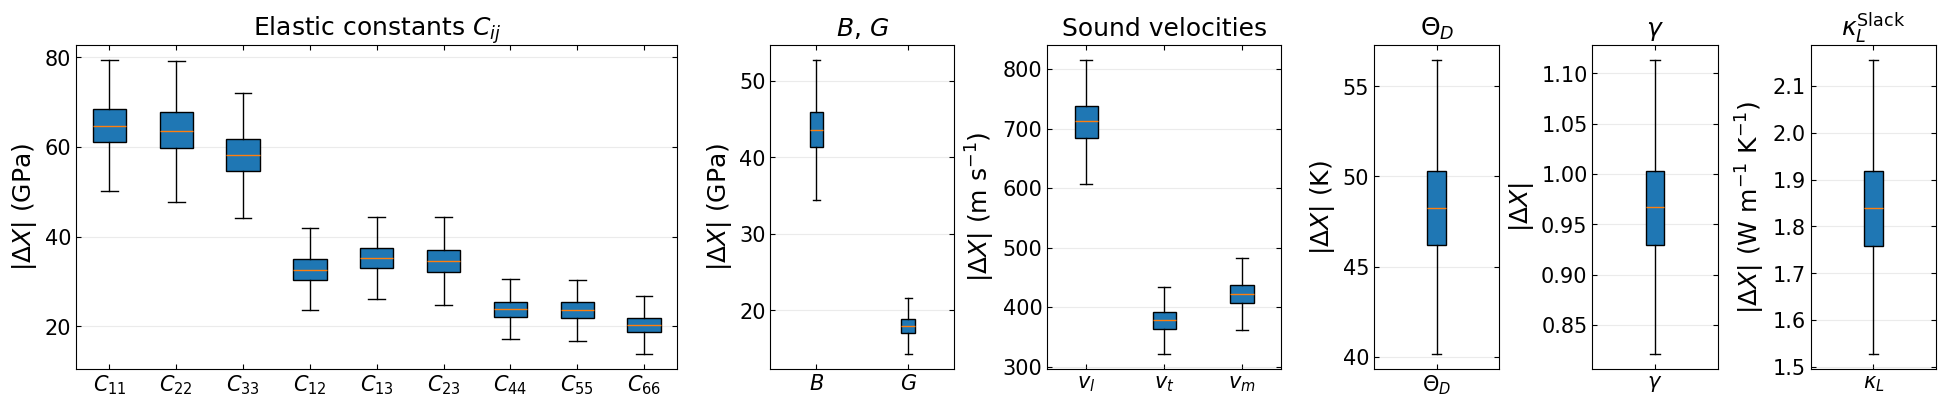

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Settings
# ============================================================

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
})


# If df_all_errors is not already loaded
if "df_all_errors" not in globals():
    df_all_errors = pd.read_csv("all_errors.csv")


# ============================================================
# Bootstrap utilities
# ============================================================

def bootstrap_ci(x, statistic="mean", n_bootstrap=5000, seed=42):
    rng = np.random.default_rng(seed)

    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan, np.nan

    if statistic == "median":
        func = np.median
    elif statistic == "mean":
        func = np.mean
    else:
        raise ValueError("statistic must be 'mean' or 'median'")

    point = func(x)

    boot = []
    for _ in range(n_bootstrap):
        sample = rng.choice(x, size=len(x), replace=True)
        boot.append(func(sample))

    boot = np.asarray(boot)

    return (
        float(point),
        float(np.percentile(boot, 2.5)),
        float(np.percentile(boot, 97.5)),
    )


def get_linear_values(quantity):
    """
    Return absolute linear errors from df_all_errors.
    This is what is plotted.
    """
    values = (
        df_all_errors
        .loc[df_all_errors["quantity"] == quantity, "error_linear"]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .abs()
        .to_numpy()
    )

    if len(values) == 0:
        raise RuntimeError(f"No linear errors found for quantity: {quantity}")

    return values


def get_linear_summary(quantity, statistic="mean", seed=42):
    """
    Summary for errors.csv.
    Uses only error_linear from df_all_errors.
    """
    values = get_linear_values(quantity)

    point, low, high = bootstrap_ci(
        values,
        statistic=statistic,
        n_bootstrap=5000,
        seed=seed,
    )

    return point, low, high


# ============================================================
# Quantities to plot
# property_name is used in plot labels
# quantity is the name inside df_all_errors["quantity"]
# ============================================================

items = [
    # Elastic constants
    ("C11", "C11", "GPa", "mean"),
    ("C22", "C22", "GPa", "mean"),
    ("C33", "C33", "GPa", "mean"),
    ("C12", "C12", "GPa", "mean"),
    ("C13", "C13", "GPa", "mean"),
    ("C23", "C23", "GPa", "mean"),
    ("C44", "C44", "GPa", "mean"),
    ("C55", "C55", "GPa", "mean"),
    ("C66", "C66", "GPa", "mean"),

    # Reuss moduli
    ("B", "B_R", "GPa", "mean"),
    ("G", "G_R", "GPa", "mean"),

    # Sound velocities and Debye temperature
    ("v_t", "v_t", "m/s", "mean"),
    ("v_l", "v_l", "m/s", "mean"),
    ("v_m", "v_m", "m/s", "mean"),
    ("Theta_D", "Theta_D", "K", "mean"),

    # Gamma and Slack
    ("gamma_EOS", "gamma", "dimensionless", "median"),
    ("k_Slack", "kappa_slack", "W/m/K", "median"),
]


# ============================================================
# Build summary table from df_all_errors only
# ============================================================

errors = []

for i, (prop, quantity, unit, statistic) in enumerate(items):
    point, low, high = get_linear_summary(
        quantity,
        statistic=statistic,
        seed=42 + i,
    )

    errors.append({
        "property": prop,
        "quantity": quantity,
        "statistic": statistic,
        "point_error": point,
        "ci95_low": low,
        "ci95_high": high,
        "unit": unit,
        "source_column": "error_linear",
    })


df_errors = pd.DataFrame(errors)
df_errors.to_csv("errors.csv", index=False)

print(df_errors.to_string(index=False))


# ============================================================
# Plot settings
# ============================================================

label_map = {
    "C11": r"$C_{11}$",
    "C22": r"$C_{22}$",
    "C33": r"$C_{33}$",
    "C12": r"$C_{12}$",
    "C13": r"$C_{13}$",
    "C23": r"$C_{23}$",
    "C44": r"$C_{44}$",
    "C55": r"$C_{55}$",
    "C66": r"$C_{66}$",

    "B": r"$B$",
    "G": r"$G$",

    "v_l": r"$v_l$",
    "v_t": r"$v_t$",
    "v_m": r"$v_m$",

    "Theta_D": r"$\Theta_D$",
    "gamma_EOS": r"$\gamma$",
    "k_Slack": r"$\kappa_L$",
}


prop_to_quantity = {
    prop: quantity
    for prop, quantity, unit, statistic in items
}


def make_values(prop, n=3000):
    row = df_errors.loc[df_errors["property"] == prop].iloc[0]

    mu = float(row["point_error"])
    low = float(row["ci95_low"])
    high = float(row["ci95_high"])

    if np.isfinite(low) and np.isfinite(high) and high > low:
        sigma = (high - low) / 3.92
        values = rng.normal(mu, sigma, n)
        values = np.clip(values, 0.0, None)
    else:
        values = np.full(n, mu)

    return values


def draw_boxplot(ax, props, ylabel, title, rotation=0):
    data = [make_values(p) for p in props]

    ax.boxplot(
        data,
        tick_labels=[label_map[p] for p in props],
        showfliers=False,
        patch_artist=True,
    )

    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=7)
    ax.tick_params(axis="x", rotation=rotation)
    ax.tick_params(axis="both", direction="in", top=True, right=True)
    ax.grid(axis="y", alpha=0.25)


# ============================================================
# Plot groups
# ============================================================

cols_cij = ["C11", "C22", "C33", "C12", "C13", "C23", "C44", "C55", "C66"]
cols_moduli = ["B", "G"]
cols_vel = ["v_l", "v_t", "v_m"]
cols_debye = ["Theta_D"]
cols_gamma = ["gamma_EOS"]
cols_kslack = ["k_Slack"]


fig = plt.figure(figsize=(24, 4.2))

gs = fig.add_gridspec(
    1,
    6,
    width_ratios=[3.6, 1.1, 1.4, 0.75, 0.75, 0.75],
    wspace=0.4,
)

axes = [fig.add_subplot(gs[0, i]) for i in range(6)]

draw_boxplot(
    axes[0],
    cols_cij,
    r"$|\Delta X|$ (GPa)",
    r"Elastic constants $C_{ij}$",
)

draw_boxplot(
    axes[1],
    cols_moduli,
    r"$|\Delta X|$ (GPa)",
    r"$B$, $G$",
)

draw_boxplot(
    axes[2],
    cols_vel,
    r"$|\Delta X|$ (m s$^{-1}$)",
    "Sound velocities",
)

draw_boxplot(
    axes[3],
    cols_debye,
    r"$|\Delta X|$ (K)",
    r"$\Theta_D$",
)

draw_boxplot(
    axes[4],
    cols_gamma,
    r"$|\Delta X|$",
    r"$\gamma$",
)

draw_boxplot(
    axes[5],
    cols_kslack,
    r"$|\Delta X|$ (W m$^{-1}$ K$^{-1}$)",
    r"$\kappa_L^{\mathrm{Slack}}$",
)

fig.savefig("elastic_error_boxplots.png", dpi=600, bbox_inches="tight")
plt.show()